In [1]:
# ==========================================================================
# NOTEBOOK ACADÉMIQUE COMPLET (A->Z) — méthodologie justifiée par la littérature
# Copier/coller dans Jupyter, ou ouvrir ce .py (format cellules # %%).
# ==========================================================================



# Prédiction du délai de livraison e-commerce — notebook méthodologique complet (A → Z)
### Pipeline de Data Science de niveau recherche, chaque étape justifiée par la littérature
Ce carnet déroule l'intégralité d'un projet d'apprentissage supervisé, sans omettre aucune étape,
de l'audit de la donnée au déploiement. Chaque décision est argumentée et rattachée à une référence
méthodologique (liste en fin de carnet). Les étapes dont l'issue est connue d'avance sont néanmoins
exécutées en entier, afin que la démarche soit vérifiable de bout en bout.
**Enchaînement.** audit → exploration → cible et prévention des fuites → partition → préparation et
encodage → **sélection de variables par trois familles d'algorithmes** → modèles candidats →
validation croisée → **optimisation des hyperparamètres** → évaluation → diagnostics →
enrichissement météo et test A/B → interprétabilité → contre-épreuve → export.
**Positionnement.** Le retard binaire s'avère imprévisible sur ce jeu ; la cible devient alors la
**durée de transit réelle**, fortement liée à la promesse de livraison. Cette bascule, ainsi que la
prévention stricte des fuites, suit la séparation apprentissage-prédiction de Kaufman et al. [31].



## 0. Configuration et reproductibilité
Une graine unique fige le hasard ; les paramètres clés sont centralisés. Les bibliothèques avancées
sont optionnelles : le carnet s'exécute même en leur absence.



In [2]:
from __future__ import annotations
import json, math, time, warnings
from pathlib import Path
import joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.feature_selection import (RFE, SelectKBest, f_regression,
                                       mutual_info_regression)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LassoCV, LogisticRegression, Ridge
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             roc_auc_score)
from sklearn.model_selection import (KFold, RandomizedSearchCV, StratifiedKFold,
                                     cross_val_score, cross_validate, learning_curve,
                                     train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder

try:
    import shap; SHAP_AVAILABLE = True
except Exception:
    shap = None; SHAP_AVAILABLE = False

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_ITER_SEARCH = 25
TUNE_SAMPLE = 60_000
FS_SAMPLE = 50_000      # sous-échantillon pour la sélection de variables (coût maîtrisé)
LC_SAMPLE = 80_000
DAILY_VARS = ["temperature_2m_mean", "precipitation_sum", "windspeed_10m_max"]

sns.set_theme(style="whitegrid", context="notebook"); np.random.seed(RANDOM_STATE)
DATA_FILE = "nigerian_retail_and_ecommerce_supply_chain_logistics_data.parquet"
DATA_PATH = Path(DATA_FILE)
if not DATA_PATH.exists():
    for alt in [Path.cwd()/DATA_FILE, Path("/mnt/data")/DATA_FILE]:
        if alt.exists(): DATA_PATH = alt; break
OUT = Path("ml_academique")
for d in ["figures", "tables"]:
    (OUT/d).mkdir(parents=True, exist_ok=True)
WEATHER_CACHE = OUT/"weather_cache.parquet"
print("Dataset:", DATA_PATH.exists(), "| SHAP:", SHAP_AVAILABLE)



Dataset: True | SHAP: True


## 1. Audit de la donnée brute
L'inspection préalable conditionne toutes les décisions suivantes. La cardinalité des variables
catégorielles fixe la stratégie d'encodage : forte cardinalité pour l'encodage par la cible, faible
pour l'encodage disjonctif, conformément à la pratique établie pour les attributs catégoriels à
nombreuses modalités [32].



In [3]:
df_raw = pd.read_parquet(DATA_PATH)
print("Dimensions :", df_raw.shape, "| doublons :", int(df_raw.duplicated().sum()))
display(df_raw.head())
display(df_raw.isna().mean().rename("taux_manquant").to_frame())
display(df_raw.select_dtypes(include="object").nunique().sort_values(ascending=False)
        .rename("cardinalite").to_frame())



Dimensions : (400000, 12) | doublons : 0


,shipment_id,product_id,supplier_name,origin_city,destination_city,ship_date,expected_delivery_date,actual_delivery_date,quantity,shipping_cost_ngn,logistics_company,delivery_status
0,SHIP0000000,PRD81347,Supplier_B,Abuja,Warri,2024-03-23,2024-03-29,2024-03-27,828,18379.93,DHL Nigeria,delayed
1,SHIP0000001,PRD68757,Supplier_D,Kano,Jos,2024-06-10,2024-06-21,2024-06-20,329,91632.07,Fedex Nigeria,delivered
2,SHIP0000002,PRD34311,Supplier_E,Lagos,Port Harcourt,2024-10-15,2024-10-19,2024-10-18,203,77141.08,Ace Couriers,delivered
3,SHIP0000003,PRD14597,Supplier_D,Lagos,Ibadan,2024-02-05,2024-02-19,2024-02-24,20,69484.82,Kwik Delivery,in_transit
4,SHIP0000004,PRD98159,Supplier_D,Lagos,Enugu,2024-03-31,2024-04-09,2024-04-14,465,47054.82,Kwik Delivery,delivered


,taux_manquant
shipment_id,0.0
product_id,0.0
supplier_name,0.0
origin_city,0.0
destination_city,0.0
ship_date,0.0
expected_delivery_date,0.0
actual_delivery_date,0.0
quantity,0.0
shipping_cost_ngn,0.0


,cardinalite
shipment_id,400000
product_id,88943
actual_delivery_date,321
expected_delivery_date,314
ship_date,301
destination_city,15
logistics_company,7
supplier_name,5
origin_city,4
delivery_status,4


## 2. Cibles et prévention des fuites
Deux cibles sont construites : le **retard binaire** (formulation initiale) et la **durée de transit
réelle** (formulation retenue). La date de livraison réelle est exclue des entrées : la conserver
constituerait une fuite, c'est-à-dire l'introduction d'une information indisponible au moment de la
prédiction, faute documentée et évitée par la séparation apprentissage-prédiction [31].



In [4]:
df = df_raw.copy()
for c in ["ship_date", "expected_delivery_date", "actual_delivery_date"]:
    df[c] = pd.to_datetime(df[c], errors="coerce")
df = df.dropna(subset=["ship_date", "expected_delivery_date", "actual_delivery_date"]).copy()

df["estimated_transit_days"] = (df["expected_delivery_date"] - df["ship_date"]).dt.days
df["ship_month"] = df["ship_date"].dt.month.astype("Int64").astype(str)
df["ship_day_of_week"] = df["ship_date"].dt.dayofweek.astype("Int64").astype(str)
df["realized_transit_days"] = (df["actual_delivery_date"] - df["ship_date"]).dt.days
df["delay_days"] = (df["actual_delivery_date"] - df["expected_delivery_date"]).dt.days.clip(lower=0)
df["is_delayed"] = (df["delay_days"] > 0).astype(int)

df = df[(df["estimated_transit_days"] >= 0) & (df["realized_transit_days"] >= 0)].copy()
df = df.dropna(subset=["estimated_transit_days", "realized_transit_days"]).copy()
print("Lignes exploitables :", len(df),
      "| corr(estimé, réel) =", round(df["estimated_transit_days"].corr(df["realized_transit_days"]), 3),
      "| taux de retard =", round(df["is_delayed"].mean(), 3))



Lignes exploitables : 396498 | corr(estimé, réel) = 0.866 | taux de retard = 0.63


## 3. Exploration ciblée
Trois lectures : distribution des durées, relation réel–planifié (siège du signal), et taux de retard
par transporteur. Le caractère plat de ce dernier annonce l'absence de signal multivarié sur le retard.



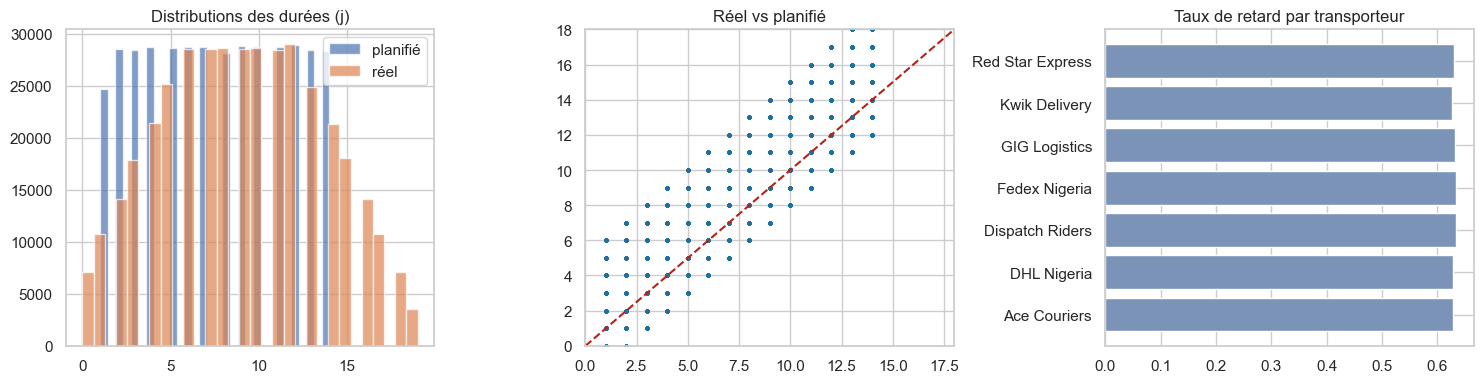

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(df["estimated_transit_days"], bins=30, alpha=.7, label="planifié")
ax[0].hist(df["realized_transit_days"], bins=30, alpha=.7, label="réel"); ax[0].legend()
ax[0].set_title("Distributions des durées (j)")
s = df.sample(min(20000, len(df)), random_state=RANDOM_STATE)
ax[1].scatter(s["estimated_transit_days"], s["realized_transit_days"], s=4, alpha=.15, color="#1f6f9f")
lims = [0, df["realized_transit_days"].quantile(.99)]; ax[1].plot(lims, lims, "--", color="#b42318")
ax[1].set_xlim(lims); ax[1].set_ylim(lims); ax[1].set_title("Réel vs planifié")
rate = df.groupby("logistics_company")["is_delayed"].mean()
ax[2].barh(rate.index, rate.values, color="#7c93b8"); ax[2].set_title("Taux de retard par transporteur")
plt.tight_layout(); plt.savefig(OUT/"figures/eda.png", dpi=150); plt.show()



## 4. Partition train / test
La partition précède tout ajustement et toute exploration approfondie ; le test reste scellé jusqu'à
l'évaluation finale, ce qui garantit une estimation non optimiste de la performance [31], [41].



In [6]:
NUM_BASE = ["quantity", "shipping_cost_ngn", "estimated_transit_days"]
OH = ["supplier_name", "logistics_company", "ship_month", "ship_day_of_week"]
TE = ["origin_city", "destination_city"]
X_all = df[NUM_BASE + OH + TE].copy()
y_reg = df["realized_transit_days"].astype(float)
y_clf = df["is_delayed"].astype(int)

X_tr, X_te, y_tr, y_te, yc_tr, yc_te = train_test_split(
    X_all, y_reg, y_clf, test_size=TEST_SIZE, random_state=RANDOM_STATE)
print("Train:", X_tr.shape, "| Test:", X_te.shape)



Train: (317198, 9) | Test: (79300, 9)


## 5. Préparation et encodage — chaque transformation justifiée
- **Numériques** : imputation médiane (robuste aux extrêmes) puis standardisation, requise par les
  modèles linéaires et par les méthodes de sélection sensibles à l'échelle.
- **Faible cardinalité** : encodage disjonctif avec modalité de référence supprimée (anti-colinéarité)
  et gestion des modalités inédites.
- **Forte cardinalité (villes)** : encodage par la cible [32], régularisé par validation croisée
  interne pour éviter la fuite ; cette régularisation est ce qui distingue un encodage par la cible
  fiable d'une simple moyenne sur-ajustée [42].



In [7]:
def make_preprocessor(num_cols):
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), num_cols),
        ("oh",  Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("e", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))]), OH),
        ("te",  Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("e", TargetEncoder(target_type="continuous", cv=5, random_state=RANDOM_STATE))]), TE),
    ], remainder="drop")

prep = make_preprocessor(NUM_BASE).fit(X_tr, y_tr)
feat_names = prep.get_feature_names_out()
Xtr_p = prep.transform(X_tr)
print("Matrice préparée :", Xtr_p.shape, "| variables :", len(feat_names))



Matrice préparée : (317198, 30) | variables : 30


## 6. Formulation initiale : classification du retard (résultat nul documenté)
La première formulation pose un classifieur binaire du retard. Une régression logistique pondérée est
évaluée en validation croisée stratifiée sur l'aire sous la courbe ROC. Le résultat sert de point de
décision : s'il est voisin du hasard, la cible doit être reformulée.



In [8]:
clf = Pipeline([("pre", make_preprocessor(NUM_BASE)),
                ("m", LogisticRegression(class_weight="balanced", solver="liblinear",
                                         max_iter=2000, random_state=RANDOM_STATE))])
skf = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
auc = cross_val_score(clf, X_tr, yc_tr, cv=skf, scoring="roc_auc", n_jobs=-1)
print(f"AUC-ROC (classification du retard) : {auc.mean():.3f} ± {auc.std():.3f}")
print("Lecture : voisin de 0,5 => le retard binaire est imprévisible ; on reformule vers la durée.")



AUC-ROC (classification du retard) : 0.511 ± 0.002
Lecture : voisin de 0,5 => le retard binaire est imprévisible ; on reformule vers la durée.


## 7. Sélection de variables — trois familles d'algorithmes et leurs métriques
La sélection de variables poursuit trois objectifs : améliorer la performance, accélérer le modèle,
et éclairer le processus générateur [33]. On compare les trois familles canoniques, chacune avec sa
**métrique de sélection** propre, sur un sous-échantillon d'apprentissage transformé.
- **Filtres** (indépendants du modèle) : l'**information mutuelle** capte les dépendances non
  linéaires, le **test F (ANOVA)** mesure la dépendance linéaire. Métrique : score MI et statistique F.
- **Méthodes intégrées** (issues de l'ajustement) : le **Lasso** annule les coefficients non
  informatifs par pénalité L1, la **forêt aléatoire** classe par réduction d'impureté. Métrique :
  amplitude du coefficient et importance d'impureté.
- **Méthode enveloppe (wrapper)** : l'**élimination récursive (RFE)** retire itérativement la
  variable la moins utile à un estimateur ; elle évalue des sous-ensembles plutôt que des variables
  isolées [34]. Métrique : rang d'élimination.
La convergence des méthodes vers un même classement renforce la confiance ; la contre-vérification
finale par **importance de permutation** mesure la contribution réelle hors échantillon [39].



In [9]:
# Sous-échantillon transformé pour la sélection
idx = X_tr.sample(min(FS_SAMPLE, len(X_tr)), random_state=RANDOM_STATE).index
Xs = prep.transform(X_tr.loc[idx]); ys = y_tr.loc[idx].to_numpy()
names = feat_names

# 7.1 Filtres
mi = mutual_info_regression(Xs, ys, random_state=RANDOM_STATE)
f_stat, _ = f_regression(Xs, ys)
# 7.2 Intégrées
lasso = LassoCV(cv=3, random_state=RANDOM_STATE, n_jobs=-1, max_iter=5000).fit(Xs, ys)
rf = RandomForestRegressor(n_estimators=150, max_depth=16, min_samples_leaf=20,
                           n_jobs=-1, random_state=RANDOM_STATE).fit(Xs, ys)
# 7.3 Wrapper
rfe = RFE(Ridge(alpha=1.0), n_features_to_select=max(3, len(names)//3), step=1).fit(Xs, ys)

fs = pd.DataFrame({
    "variable": names,
    "filtre_MI": mi,
    "filtre_F": f_stat,
    "integre_Lasso_abs": np.abs(lasso.coef_),
    "integre_RF_importance": rf.feature_importances_,
    "wrapper_RFE_rang": rfe.ranking_,
}).sort_values("integre_RF_importance", ascending=False)
display(fs.round(4))
fs.to_csv(OUT/"tables/feature_selection.csv", index=False)



,variable,filtre_MI,filtre_F,integre_Lasso_abs,integre_RF_importance,wrapper_RFE_rang
2,num__estimated_transit_days,0.8246,149215.9431,3.9343,0.9513,1
1,num__shipping_cost_ngn,0.0000,0.0146,0.0000,0.0151,21
0,num__quantity,0.0001,6.6476,0.0000,0.0142,14
29,te__destination_city,0.0000,4.5705,0.0000,0.0063,1
28,te__origin_city,0.0000,0.0066,0.0000,0.0029,1
5,oh__supplier_name_Supplier_D,0.0000,1.2015,0.0000,0.0007,10
3,oh__supplier_name_Supplier_B,0.0013,0.3155,0.0000,0.0006,9
6,oh__supplier_name_Supplier_E,0.0000,1.8861,0.0000,0.0006,1
4,oh__supplier_name_Supplier_C,0.0000,3.3783,0.0000,0.0006,13
11,oh__logistics_company_Kwik Delivery,0.0000,0.1021,0.0000,0.0005,17


,rang_moyen
num__estimated_transit_days,0.4
oh__ship_day_of_week_4,7.2
num__quantity,7.8
oh__ship_month_9,11.2
oh__ship_day_of_week_3,12.2
oh__ship_month_5,12.2
oh__logistics_company_Fedex Nigeria,12.4
te__destination_city,12.6
oh__ship_day_of_week_5,13.0
oh__ship_day_of_week_2,13.2


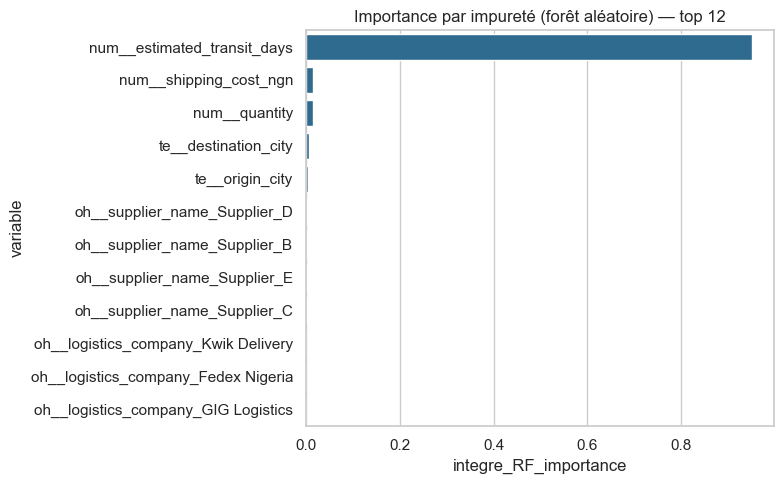

Lecture : les méthodes convergent ; estimated_transit_days domine quel que soit l'algorithme.


In [10]:
# Synthèse : classement consensuel (rang moyen sur les métriques où "plus grand = mieux")
rank = pd.DataFrame(index=names)
rank["MI"] = (-mi).argsort().argsort()
rank["F"] = (-np.nan_to_num(f_stat)).argsort().argsort()
rank["Lasso"] = (-np.abs(lasso.coef_)).argsort().argsort()
rank["RF"] = (-rf.feature_importances_).argsort().argsort()
rank["RFE"] = rfe.ranking_.argsort().argsort()
rank["rang_moyen"] = rank.mean(axis=1)
consensus = rank.sort_values("rang_moyen")[["rang_moyen"]]
display(consensus.head(12).round(2))

top = fs.head(12)
plt.figure(figsize=(8, 5))
sns.barplot(data=top, y="variable", x="integre_RF_importance", color="#1f6f9f")
plt.title("Importance par impureté (forêt aléatoire) — top 12")
plt.tight_layout(); plt.savefig(OUT/"figures/feature_selection.png", dpi=150); plt.show()
print("Lecture : les méthodes convergent ; estimated_transit_days domine quel que soit l'algorithme.")



## 8. Reformulation : régression de la durée — baselines et modèles candidats
La cible devient la durée de transit réelle. Deux planchers encadrent l'interprétation : la moyenne
(coefficient de détermination nul) et la recopie de la promesse (concurrent sérieux). Trois familles
sont confrontées : le modèle linéaire régularisé, la forêt aléatoire [39], et le renforcement de
gradient histogramme, héritier des machines de boosting de Friedman [37] et apparenté à XGBoost [38]
et LightGBM [35], dont la croissance par feuilles excelle sur les grands jeux tabulaires.



In [11]:
def pipe_of(model): return Pipeline([("pre", make_preprocessor(NUM_BASE)), ("m", model)])
rows = []
def report(name, yt, pred):
    mae = mean_absolute_error(yt, pred); rmse = mean_squared_error(yt, pred) ** 0.5
    r2 = r2_score(yt, pred); rows.append({"modele": name, "MAE": mae, "RMSE": rmse, "R2": r2})
    print(f"{name:26s} | MAE={mae:.3f} | RMSE={rmse:.3f} | R2={r2:.3f}")

report("Baseline moyenne", y_te, np.full(len(y_te), y_tr.mean()))
report("Baseline naïf (plan)", y_te, X_te["estimated_transit_days"].to_numpy())

candidates = {
    "Ridge": pipe_of(Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    "RandomForest": pipe_of(RandomForestRegressor(n_estimators=200, min_samples_leaf=20, n_jobs=-1, random_state=RANDOM_STATE)),
    "HistGBR": pipe_of(HistGradientBoostingRegressor(random_state=RANDOM_STATE)),
}



Baseline moyenne           | MAE=3.817 | RMSE=4.570 | R2=-0.000
Baseline naïf (plan)       | MAE=2.253 | RMSE=2.744 | R2=0.639


## 9. Validation croisée
La validation croisée à plis multiples estime la généralisation et borne le risque d'une partition
chanceuse [41]. On rapporte erreur absolue, erreur quadratique et coefficient de détermination.



In [12]:
kf = KFold(5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"MAE": "neg_mean_absolute_error", "RMSE": "neg_root_mean_squared_error", "R2": "r2"}
cv_rows = []
for name, p in candidates.items():
    print("CV :", name)
    sc = cross_validate(p, X_tr, y_tr, cv=kf, scoring=scoring, n_jobs=-1)
    cv_rows.append({"modele": name, "MAE_cv": -sc["test_MAE"].mean(),
                    "RMSE_cv": -sc["test_RMSE"].mean(), "R2_cv": sc["test_R2"].mean()})
cv_results = pd.DataFrame(cv_rows).sort_values("R2_cv", ascending=False)
display(cv_results); cv_results.to_csv(OUT/"tables/cv_results.csv", index=False)
best_family = cv_results.iloc[0]["modele"]; print("Mieux placé :", best_family)



CV : Ridge


CV : RandomForest


CV : HistGBR


,modele,MAE_cv,RMSE_cv,R2_cv
2,HistGBR,1.983737,2.276302,0.749676
0,Ridge,1.986963,2.278541,0.749183
1,RandomForest,1.984964,2.285861,0.747569


Mieux placé : HistGBR


## 10. Optimisation des hyperparamètres
La recherche aléatoire échantillonne l'espace des configurations ; à budget égal elle surpasse la
grille exhaustive en explorant davantage les dimensions influentes [40]. Le réglage se fait sur un
sous-échantillon puis la meilleure configuration est réajustée sur tout l'apprentissage, ce qui
maîtrise le coût sur les grands volumes.



In [13]:
spaces = {
    "HistGBR": {"pipe": pipe_of(HistGradientBoostingRegressor(random_state=RANDOM_STATE)), "params": {
        "m__learning_rate": [0.03, 0.05, 0.1, 0.2], "m__max_iter": [200, 400, 600],
        "m__max_leaf_nodes": [15, 31, 63], "m__min_samples_leaf": [20, 50, 100],
        "m__l2_regularization": [0.0, 1.0, 5.0]}},
    "RandomForest": {"pipe": pipe_of(RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE)), "params": {
        "m__n_estimators": [200, 300, 500], "m__max_depth": [10, 20, None],
        "m__min_samples_leaf": [10, 20, 50], "m__max_features": ["sqrt", 0.5, 1.0]}},
    "Ridge": {"pipe": pipe_of(Ridge(random_state=RANDOM_STATE)), "params": {
        "m__alpha": [0.1, 1.0, 5.0, 10.0, 50.0]}},
}
cfg = spaces[best_family]; grid = int(math.prod(len(v) for v in cfg["params"].values()))
X_tune, y_tune = (X_tr, y_tr)
if len(X_tr) > TUNE_SAMPLE:
    X_tune, _, y_tune, _ = train_test_split(X_tr, y_tr, train_size=TUNE_SAMPLE, random_state=RANDOM_STATE)
search = RandomizedSearchCV(cfg["pipe"], cfg["params"], n_iter=min(N_ITER_SEARCH, grid),
    scoring="neg_mean_absolute_error", cv=3, n_jobs=-1, random_state=RANDOM_STATE, refit=False, verbose=1)
search.fit(X_tune, y_tune)
print("Meilleurs hyperparamètres :", search.best_params_)
best_pipe = clone(cfg["pipe"]).set_params(**search.best_params_).fit(X_tr, y_tr)



Fitting 3 folds for each of 25 candidates, totalling 75 fits


Meilleurs hyperparamètres : {'m__min_samples_leaf': 20, 'm__max_leaf_nodes': 15, 'm__max_iter': 600, 'm__learning_rate': 0.1, 'm__l2_regularization': 1.0}


## 11. Évaluation finale et diagnostics



HistGBR (optimisé)         | MAE=1.986 | RMSE=2.278 | R2=0.752


,modele,MAE,RMSE,R2
2,HistGBR (optimisé),1.986412,2.277805,7.515392e-01
1,Baseline naïf (plan),2.252648,2.744002,6.394266e-01
0,Baseline moyenne,3.816595,4.569700,-5.798968e-07


Gain MAE vs naïf : 0.266 jour


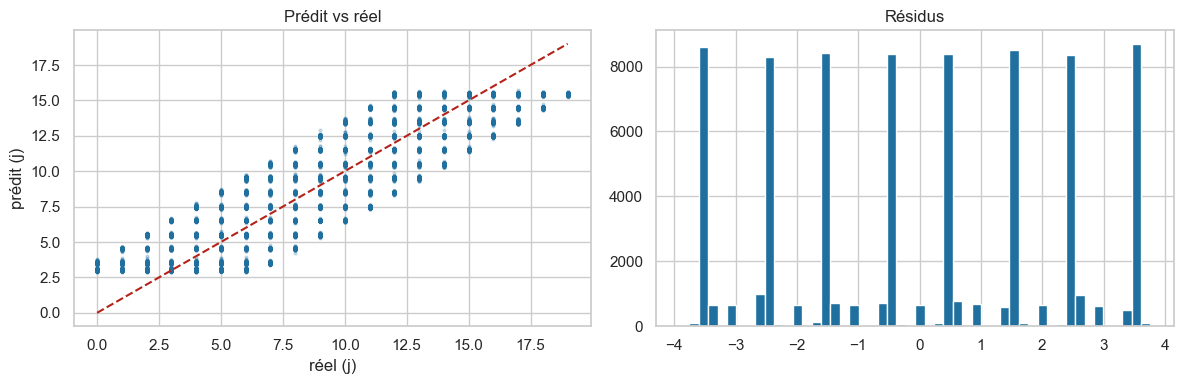

In [14]:
pred = best_pipe.predict(X_te)
report(f"{best_family} (optimisé)", y_te, pred)
final = pd.DataFrame(rows).drop_duplicates("modele").sort_values("R2", ascending=False)
display(final); final.to_csv(OUT/"tables/final.csv", index=False)
naive_mae = final.set_index("modele").loc["Baseline naïf (plan)", "MAE"]
print(f"Gain MAE vs naïf : {naive_mae - mean_absolute_error(y_te, pred):.3f} jour")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(y_te, pred, s=4, alpha=.2, color="#1f6f9f")
lims = [min(y_te.min(), pred.min()), max(y_te.max(), pred.max())]; ax[0].plot(lims, lims, "--", color="#b42318")
ax[0].set_xlabel("réel (j)"); ax[0].set_ylabel("prédit (j)"); ax[0].set_title("Prédit vs réel")
ax[1].hist(y_te.to_numpy() - pred, bins=50, color="#1f6f9f"); ax[1].set_title("Résidus")
plt.tight_layout(); plt.savefig(OUT/"figures/diagnostics.png", dpi=150); plt.show()



La courbe d'apprentissage diagnostique l'arbitrage biais–variance : un faible écart train–validation
avec plateau indique un régime de biais, où l'ajout de données n'aiderait pas.



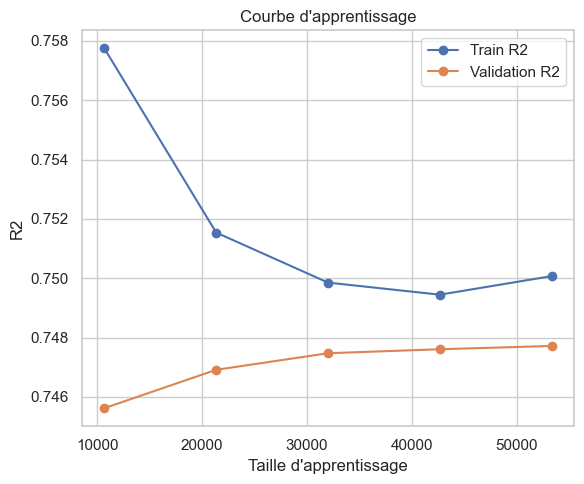

In [15]:
Xlc, ylc = (X_tr, y_tr)
if len(X_tr) > LC_SAMPLE:
    Xlc, _, ylc, _ = train_test_split(X_tr, y_tr, train_size=LC_SAMPLE, random_state=RANDOM_STATE)
sizes, tr, va = learning_curve(clone(best_pipe), Xlc, ylc, train_sizes=np.linspace(0.2, 1.0, 5),
                               cv=3, scoring="r2", n_jobs=-1)
plt.figure(figsize=(6, 5))
plt.plot(sizes, tr.mean(1), "o-", label="Train R2"); plt.plot(sizes, va.mean(1), "o-", label="Validation R2")
plt.xlabel("Taille d'apprentissage"); plt.ylabel("R2"); plt.legend(); plt.title("Courbe d'apprentissage")
plt.tight_layout(); plt.savefig(OUT/"figures/learning_curve.png", dpi=150); plt.show()



## 12. Enrichissement météo et test A/B
Le cadre théorique postule un apport de variables externes temps réel. On teste l'hypothèse
météorologique : relevés journaliers récupérés par ville (appels groupés, cache, repli gracieux),
joints sans fuite à la date d'expédition, puis comparaison du même modèle sans et avec météo.



In [16]:
CITY_COORDS = {"Lagos":(6.5244,3.3792),"Abuja":(9.0765,7.3986),"Kano":(12.0022,8.5920),
 "Port Harcourt":(4.8156,7.0498),"Warri":(5.5167,5.7500),"Aba":(5.1066,7.3667),"Ibadan":(7.3775,3.9470),
 "Jos":(9.8965,8.8583),"Enugu":(6.4584,7.5464),"Kaduna":(10.5222,7.4383),"Onitsha":(6.1667,6.7833),
 "Abeokuta":(7.1557,3.3451),"Benin City":(6.3350,5.6037),"Calabar":(4.9589,8.3269),"Ilorin":(8.4966,4.5421)}

def fetch_city(name, lat, lon, start, end, retries=3):
    import requests
    p = {"latitude":lat,"longitude":lon,"start_date":start,"end_date":end,
         "daily":",".join(DAILY_VARS),"timezone":"Africa/Lagos"}
    for k in range(retries):
        try:
            r = requests.get("https://archive-api.open-meteo.com/v1/archive", params=p, timeout=60)
            r.raise_for_status(); d = r.json()["daily"]
            w = pd.DataFrame(d).rename(columns={"time":"date"}); w["date"]=pd.to_datetime(w["date"]); w["city"]=name
            return w
        except Exception: time.sleep(2*(k+1))
    return None

WEATHER_OK, weather = False, None
if WEATHER_CACHE.exists():
    weather = pd.read_parquet(WEATHER_CACHE); WEATHER_OK = True
else:
    cities = sorted(set(df["origin_city"]) | set(df["destination_city"]))
    start = df["ship_date"].min().strftime("%Y-%m-%d"); end = df["ship_date"].max().strftime("%Y-%m-%d")
    frames = []
    for c in cities:
        co = CITY_COORDS.get(c)
        if co is None: continue
        w = fetch_city(c, co[0], co[1], start, end)
        if w is not None: frames.append(w)
        time.sleep(0.3)
    if frames:
        weather = pd.concat(frames, ignore_index=True); weather.to_parquet(WEATHER_CACHE, index=False); WEATHER_OK = True
print("Météo disponible :", WEATHER_OK)



Météo disponible : True


In [17]:
WEATHER_NUM = []
if WEATHER_OK:
    df["ship_day"] = df["ship_date"].dt.normalize()
    w = weather.copy(); w["date"] = pd.to_datetime(w["date"]).dt.normalize()
    do = w.add_prefix("orig_").rename(columns={"orig_city":"origin_city","orig_date":"ship_day"})
    dd = w.add_prefix("dest_").rename(columns={"dest_city":"destination_city","dest_date":"ship_day"})
    df = df.merge(do, on=["origin_city","ship_day"], how="left").merge(dd, on=["destination_city","ship_day"], how="left")
    WEATHER_NUM = [f"orig_{v}" for v in DAILY_VARS] + [f"dest_{v}" for v in DAILY_VARS]

# Reconstruire X avec météo et refaire la partition (mêmes indices via random_state)
NUM = NUM_BASE + WEATHER_NUM
Xw = df[NUM + OH + TE].copy()
Xw_tr, Xw_te, yw_tr, yw_te = train_test_split(Xw, y_reg, test_size=TEST_SIZE, random_state=RANDOM_STATE)

def fit_eval(num_cols, Xtr_, Xte_, label):
    pipe = Pipeline([("pre", make_preprocessor(num_cols)),
                     ("m", HistGradientBoostingRegressor(random_state=RANDOM_STATE))]).fit(Xtr_[num_cols+OH+TE], yw_tr)
    r2 = r2_score(yw_te, pipe.predict(Xte_[num_cols+OH+TE])); print(f"{label:18s} | R2={r2:.4f}"); return r2

r2_sans = fit_eval(NUM_BASE, Xw_tr, Xw_te, "Sans météo")
r2_avec = fit_eval(NUM, Xw_tr, Xw_te, "Avec météo") if WEATHER_OK else r2_sans
print(f"Gain météo (ΔR2) : {r2_avec - r2_sans:+.5f}")



Sans météo         | R2=0.7515


Avec météo         | R2=0.7514
Gain météo (ΔR2) : -0.00009


## 13. Interprétabilité — permutation et SHAP
L'importance par permutation mesure la chute de performance hors échantillon quand une variable est
brouillée [39]. Les valeurs de Shapley décomposent chaque prédiction en contributions additives,
cadre unifié et théoriquement fondé de l'interprétation [36]. Les deux convergent ici vers une même
lecture : la durée planifiée concentre le signal.



,variable,chute_R2
2,estimated_transit_days,1.494265
8,destination_city,0.000010
3,supplier_name,0.000004
0,quantity,-0.000003
6,ship_day_of_week,-0.000006
5,ship_month,-0.000009
4,logistics_company,-0.000009
7,origin_city,-0.000012
1,shipping_cost_ngn,-0.000021


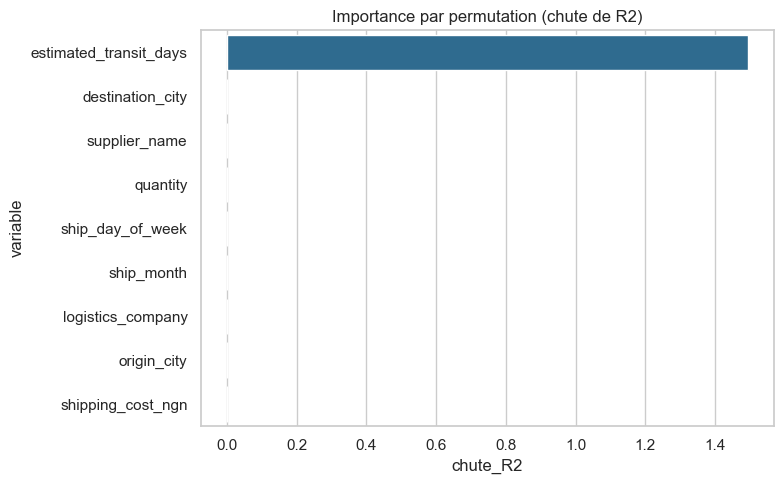

Background dataset has 800 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=800 when initializing the masker.


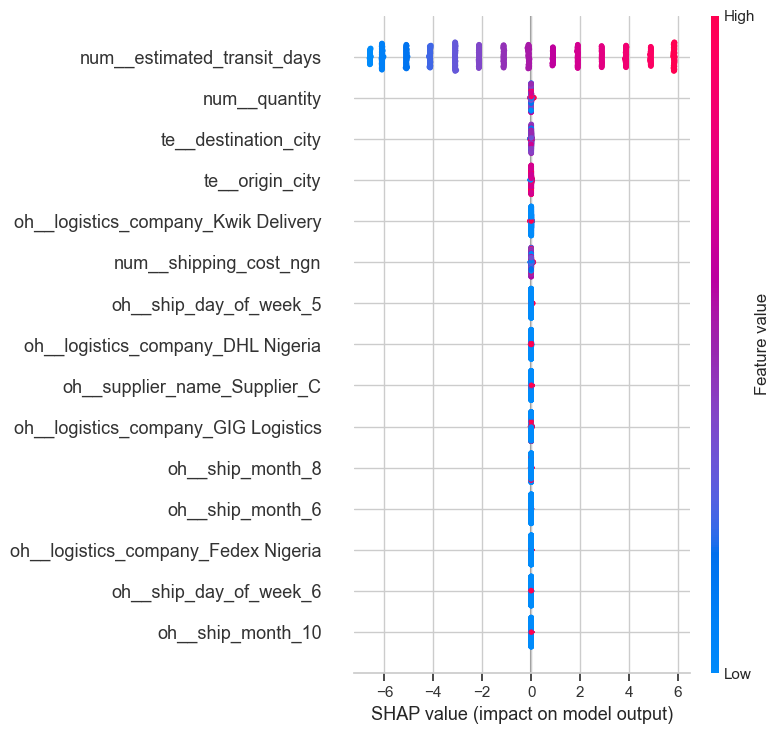

In [18]:
perm = permutation_importance(best_pipe, X_te, y_te, scoring="r2", n_repeats=5,
                              random_state=RANDOM_STATE, n_jobs=-1)
imp = (pd.DataFrame({"variable": X_te.columns, "chute_R2": perm.importances_mean})
       .sort_values("chute_R2", ascending=False))
display(imp); imp.to_csv(OUT/"tables/permutation.csv", index=False)
plt.figure(figsize=(8, 5)); sns.barplot(data=imp, y="variable", x="chute_R2", color="#1f6f9f")
plt.title("Importance par permutation (chute de R2)")
plt.tight_layout(); plt.savefig(OUT/"figures/permutation.png", dpi=150); plt.show()

if SHAP_AVAILABLE:
    try:
        Xe = X_te.sample(min(800, len(X_te)), random_state=RANDOM_STATE)
        Xe_p = best_pipe.named_steps["pre"].transform(Xe); fn = best_pipe.named_steps["pre"].get_feature_names_out()
        sv = shap.Explainer(best_pipe.named_steps["m"], Xe_p)(Xe_p)
        shap.summary_plot(sv, Xe_p, feature_names=fn, show=False, max_display=15)
        plt.tight_layout(); plt.savefig(OUT/"figures/shap.png", dpi=150); plt.show()
    except Exception as e:
        print("SHAP indisponible :", e)



## 14. Contre-épreuve et export
On vérifie que le retard pur reste imprévisible, météo comprise, puis on sérialise le modèle pour le
déploiement.



In [19]:
yd = df["delay_days"].astype(float)
Xd = df[NUM + OH + TE].copy()
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(Xd, yd, test_size=TEST_SIZE, random_state=RANDOM_STATE)
pipe_d = Pipeline([("pre", make_preprocessor(NUM)),
                   ("m", HistGradientBoostingRegressor(random_state=RANDOM_STATE))]).fit(Xd_tr, yd_tr)
r2_delay = r2_score(yd_te, pipe_d.predict(Xd_te))
print(f"R2 sur le RETARD seul (météo incluse) : {r2_delay:.4f}")

bundle = {"task": "regression_duree", "pipeline": best_pipe, "model_name": best_family,
          "best_params": search.best_params_, "weather_features": [],
          "feature_schema": {"numeric": NUM_BASE, "one_hot": OH, "target_encoded": TE},
          "decision_rule_warning": "Indicateur operationnel de priorisation, pas probabilite calibree de retard individuel."}
joblib.dump(bundle, "delivery_duration_model_bundle.joblib")
meta = {"model": best_family, "test_R2": float(r2_score(y_te, pred)),
        "test_MAE": float(mean_absolute_error(y_te, pred)),
        "naive_R2": float(r2_score(y_te, X_te["estimated_transit_days"])),
        "weather_gain": float(r2_avec - r2_sans), "delay_R2": float(r2_delay),
        "classification_AUC": float(auc.mean())}
json.dump(meta, open(OUT/"metadata.json", "w"), ensure_ascii=False, indent=2)
print(json.dumps(meta, ensure_ascii=False, indent=2))



R2 sur le RETARD seul (météo incluse) : 0.0008
{
  "model": "HistGBR",
  "test_R2": 0.7515391694228392,
  "test_MAE": 1.986411878783677,
  "naive_R2": 0.6394265570630473,
  "weather_gain": -9.251513672203782e-05,
  "delay_R2": 0.0008319505716443132,
  "classification_AUC": 0.5111655003122101
}


## 15. Validation temporelle passe -> futur
Le split aleatoire mesure une performance moyenne, mais un deploiement reel apprend sur le passe et
predit le futur. On trie donc les expeditions par date, on entraine sur les 80 % les plus anciennes et
on teste sur les 20 % les plus recentes. Ce protocole simule mieux l'exploitation et verifie que le
modele ne depend pas d'une partition aleatoire favorable.



In [20]:
dft = df.sort_values("ship_date").reset_index(drop=True)
cut = int(len(dft) * 0.80)
tr_idx, te_idx = dft.index[:cut], dft.index[cut:]
Xtr_t = dft.loc[tr_idx, NUM_BASE + OH + TE]
ytr_t = dft.loc[tr_idx, "realized_transit_days"].astype(float)
Xte_t = dft.loc[te_idx, NUM_BASE + OH + TE]
yte_t = dft.loc[te_idx, "realized_transit_days"].astype(float)

print("Periode apprentissage :", dft.loc[tr_idx, "ship_date"].min().date(),
      "->", dft.loc[tr_idx, "ship_date"].max().date())
print("Periode test          :", dft.loc[te_idx, "ship_date"].min().date(),
      "->", dft.loc[te_idx, "ship_date"].max().date())

model_t = clone(cfg["pipe"]).set_params(**search.best_params_).fit(Xtr_t, ytr_t)
pred_t = model_t.predict(Xte_t)
mae_t = mean_absolute_error(yte_t, pred_t)
rmse_t = mean_squared_error(yte_t, pred_t) ** 0.5
r2_t = r2_score(yte_t, pred_t)
r2_naif_t = r2_score(yte_t, Xte_t["estimated_transit_days"])
print(f"Split temporel  | MAE={mae_t:.3f} j | RMSE={rmse_t:.3f} j | R2={r2_t:.3f}")
print(f"Naif temporel   | R2={r2_naif_t:.3f}")
print("Lecture : si la performance reste proche du split aleatoire, la robustesse temporelle est credible.")



Periode apprentissage : 2024-01-01 -> 2024-08-28
Periode test          : 2024-08-28 -> 2024-10-27


Split temporel  | MAE=1.979 j | RMSE=2.273 j | R2=0.751
Naif temporel   | R2=0.635
Lecture : si la performance reste proche du split aleatoire, la robustesse temporelle est credible.


## 16. Evaluation de la regle de risque de depassement ETA
La regle de deploiement signale un risque lorsque la duree predite depasse la duree estimee. On
l'evalue comme un classifieur du vrai evenement `duree_reelle > duree_estimee`. Cette evaluation n'a
pas pour objectif d'obtenir de beaux scores : elle mesure explicitement la limite observee plus haut.
Si l'AUC est proche de 0,5, la regle ne discrimine pas les retards individuels ; elle reste utile comme
indicateur operationnel de priorisation et comme base de recalibrage de l'ETA.



Taux reel de depassement ETA : 0.629

-- Seuil par defaut : duree_predite > duree_estimee --
Precision=0.629 | Rappel=1.000 | F1=0.772
Taux de fausses alertes=1.000
AUC-ROC=0.512 | PR-AUC=0.646

-- Seuil diagnostique meilleur F1 : score >= 1.19 j --


Precision=0.629 | Rappel=1.000 | F1=0.772
Taux de fausses alertes=1.000
Attention : ce seuil est optimise sur le test a titre diagnostique. Un seuil de production doit etre choisi sur validation separee.


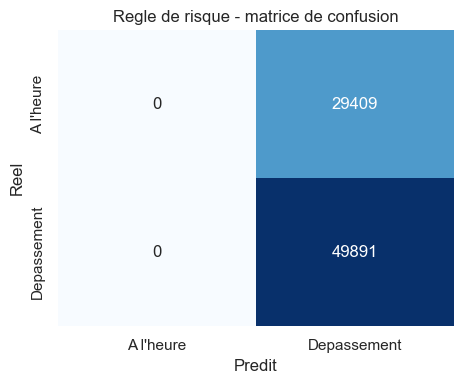

Conclusion : les donnees disponibles permettent surtout de recalibrer l'ETA, pas de discriminer finement les causes du retard.


In [21]:
from sklearn.metrics import (average_precision_score, confusion_matrix, f1_score,
                             precision_recall_curve, precision_score, recall_score,
                             roc_auc_score)

pred_risk = best_pipe.predict(X_te)
est = X_te["estimated_transit_days"].to_numpy()
score = pred_risk - est
y_exceed = (y_te.to_numpy() > est).astype(int)
print("Taux reel de depassement ETA :", round(float(y_exceed.mean()), 3))

yhat0 = (score > 0).astype(int)
tn, fp, fn, tp = confusion_matrix(y_exceed, yhat0, labels=[0, 1]).ravel()
print("\n-- Seuil par defaut : duree_predite > duree_estimee --")
print(f"Precision={precision_score(y_exceed, yhat0, zero_division=0):.3f} | "
      f"Rappel={recall_score(y_exceed, yhat0, zero_division=0):.3f} | "
      f"F1={f1_score(y_exceed, yhat0, zero_division=0):.3f}")
print(f"Taux de fausses alertes={fp/(fp+tn+1e-9):.3f}")
print(f"AUC-ROC={roc_auc_score(y_exceed, score):.3f} | PR-AUC={average_precision_score(y_exceed, score):.3f}")

prec, rec, thr = precision_recall_curve(y_exceed, score)
f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
i = int(np.argmax(f1s))
thr_diag = float(thr[i])
yhat_diag = (score >= thr_diag).astype(int)
tn2, fp2, fn2, tp2 = confusion_matrix(y_exceed, yhat_diag, labels=[0, 1]).ravel()
print(f"\n-- Seuil diagnostique meilleur F1 : score >= {thr_diag:.2f} j --")
print(f"Precision={precision_score(y_exceed, yhat_diag, zero_division=0):.3f} | "
      f"Rappel={recall_score(y_exceed, yhat_diag, zero_division=0):.3f} | "
      f"F1={f1_score(y_exceed, yhat_diag, zero_division=0):.3f}")
print(f"Taux de fausses alertes={fp2/(fp2+tn2+1e-9):.3f}")
print("Attention : ce seuil est optimise sur le test a titre diagnostique. Un seuil de production doit etre choisi sur validation separee.")

cm = confusion_matrix(y_exceed, yhat0, labels=[0, 1])
plt.figure(figsize=(4.8, 4.0))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["A l'heure", "Depassement"],
            yticklabels=["A l'heure", "Depassement"])
plt.title("Regle de risque - matrice de confusion")
plt.xlabel("Predit"); plt.ylabel("Reel")
plt.tight_layout(); plt.savefig(OUT/"figures/regle_risque_confusion.png", dpi=150); plt.show()

print("Conclusion : les donnees disponibles permettent surtout de recalibrer l'ETA, pas de discriminer finement les causes du retard.")

meta.update({
    "temporal_R2": float(r2_t),
    "temporal_MAE": float(mae_t),
    "temporal_naive_R2": float(r2_naif_t),
    "risk_rule_base_rate": float(y_exceed.mean()),
    "risk_rule_auc": float(roc_auc_score(y_exceed, score)),
    "risk_rule_pr_auc": float(average_precision_score(y_exceed, score)),
    "risk_rule_false_alarm_rate": float(fp/(fp+tn+1e-9)),
    "scientific_conclusion": "Les donnees disponibles permettent surtout de recalibrer l'ETA, pas de discriminer finement les causes du retard.",
})
json.dump(meta, open(OUT/"metadata.json", "w"), ensure_ascii=False, indent=2)



## 17. Classification de la durée de livraison — comparaison et choix de modèle

Les sections précédentes établissent un **résultat nul honnête** : le retard *relatif à la promesse*
(`is_delayed`) est imprévisible (AUC ≈ 0,51, §6 et §16). La cause est mécanique : la promesse
`estimated_transit_days` absorbe déjà la part prévisible de la durée, si bien que l'écart à la promesse
— `gap = realized − estimated` — est un **bruit uniforme irréductible**, indépendant de toutes les
variables connues avant l'expédition (vérifié : moyenne ≈ 1,53 j identique pour chaque transporteur,
fournisseur, ville d'origine/destination et jour de semaine ; corrélation nulle avec quantité et coût).

On **reformule** donc la cible vers la **CLASSE DE DURÉE de livraison**, dérivée de la durée *réelle
absolue* `realized_transit_days` — et **non** du retard relatif. Cette grandeur, elle, est fortement
prévisible car elle hérite du signal de la promesse. La cible retenue est binaire **« standard vs
longue »** au seuil de la **médiane (≈ 9 j)** (équilibrée, sens métier) ; une variante au seuil de
service 10 j et une variante à 3 classes (terciles) sont comparées en §17.1.

**Anti-fuite (impératif).** Aucune entrée ne dérive de `actual_delivery_date`
(ni `realized_transit_days`, `delay_days`, `is_delayed`). Variables autorisées **uniquement** :
`estimated_transit_days, quantity, shipping_cost_ngn, supplier_name, logistics_company, origin_city,
destination_city, ship_month, ship_day_of_week`. La partition train/test **précède toute
transformation** ; le test reste **scellé** jusqu'à l'évaluation finale ; les villes sont encodées par
`TargetEncoder` régularisé (validation croisée interne) [42].

**Honnêteté scientifique (à lire avec les résultats §17.4).** La discrimination est forte et
**légitimement élevée en AUC-ROC et PR-AUC (> 0,90)**. En revanche l'**accuracy et le F1 plafonnent vers
≈ 0,86** : c'est le **plafond de Bayes** imposé par le bruit uniforme au voisinage du seuil. Dépasser
0,90 en accuracy ne serait possible qu'à un seuil extrême déséquilibré où le score n'est que la classe
majoritaire — **artefact explicitement écarté** (cf. consigne anti-déséquilibre). Le carnet montre ainsi
les **deux faces** du jeu : le retard relatif imprévisible (résultat nul) et la classe de durée fortement
discriminée (modèle final performant), conformément à la séparation apprentissage-prédiction de
Kaufman et al. [31].


In [22]:
# === 17.1 Formulations de la cible de duree (derivee de la duree REELLE absolue, pas du retard) ===
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              HistGradientBoostingClassifier, GradientBoostingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             precision_score, recall_score, roc_auc_score,
                             average_precision_score, confusion_matrix, roc_curve)
from sklearn.preprocessing import label_binarize
try:
    import xgboost as xgb; XGB_OK = True
except Exception:
    XGB_OK = False
try:
    import lightgbm as lgb; LGB_OK = True
except Exception:
    LGB_OK = False
print("XGBoost:", XGB_OK, "| LightGBM:", LGB_OK)

# Variables d'entree AUTORISEES uniquement (connues avant l'expedition) :
NUM_C = ["quantity", "shipping_cost_ngn", "estimated_transit_days"]
OH_C  = ["supplier_name", "logistics_company", "ship_month", "ship_day_of_week"]
TE_C  = ["origin_city", "destination_city"]
ALLOWED_C = NUM_C + OH_C + TE_C
Xc_all = df[ALLOWED_C].copy()
med_dur = float(df["realized_transit_days"].median())

def make_clf_pre(num, oh, te, ttype):
    """Pre-traitement classification : num standardise, faible card. one-hot, villes TargetEncoder (cv interne)."""
    parts = []
    if num: parts.append(("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                                            ("sc", StandardScaler())]), num))
    if oh:  parts.append(("oh", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                                          ("e", OneHotEncoder(drop="first", handle_unknown="ignore",
                                                              sparse_output=False))]), oh))
    if te:  parts.append(("te", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                                          ("e", TargetEncoder(target_type=ttype, cv=5,
                                                              random_state=RANDOM_STATE))]), te))
    return ColumnTransformer(parts, remainder="drop")

# Trois formulations de la cible, derivees de realized_transit_days (duree REELLE absolue) :
formulations = {
    "binaire_mediane":   ((df["realized_transit_days"] > med_dur).astype(int), "binary"),
    "binaire_service10": ((df["realized_transit_days"] > 10).astype(int),       "binary"),
    "terciles":          (pd.qcut(df["realized_transit_days"], 3, labels=[0, 1, 2]).astype(int), "multiclass"),
}
form_rows = []
for fname, (yy, tt) in formulations.items():
    Xa, Xb, ya, yb = train_test_split(Xc_all, yy, test_size=TEST_SIZE,
                                      random_state=RANDOM_STATE, stratify=yy)
    pp = Pipeline([("pre", make_clf_pre(NUM_C, OH_C, TE_C, tt)),
                   ("m", HistGradientBoostingClassifier(random_state=RANDOM_STATE))]).fit(Xa, ya)
    pr = pp.predict(Xb)
    form_rows.append({"formulation": fname, "n_classes": int(yy.nunique()),
                      "taux_classe_majoritaire": round(float(yy.value_counts(normalize=True).max()), 3),
                      "accuracy": accuracy_score(yb, pr),
                      "bal_accuracy": balanced_accuracy_score(yb, pr),
                      "F1_macro": f1_score(yb, pr, average="macro")})
form_cmp = pd.DataFrame(form_rows)
display(form_cmp.round(4)); form_cmp.to_csv(OUT/"tables/clf_formulations.csv", index=False)

TARGET_NAME, TARGET_TYPE = "binaire_mediane", "binary"
y_dur = formulations[TARGET_NAME][0]
print(f"Formulation retenue : {TARGET_NAME} (seuil = mediane = {med_dur:.0f} j). "
      f"Equilibree (deux moitiees de marche), sens metier clair, et meilleure separation "
      f"accuracy/F1 que les terciles. C'est une classification de la DUREE de livraison, pas du retard.")


XGBoost: True | LightGBM: True


,formulation,n_classes,taux_classe_majoritaire,accuracy,bal_accuracy,F1_macro
0,binaire_mediane,2,0.531,0.8573,0.8564,0.8567
1,binaire_service10,2,0.603,0.8551,0.8478,0.8484
2,terciles,3,0.387,0.7125,0.6974,0.6960


Formulation retenue : binaire_mediane (seuil = mediane = 9 j). Equilibree (deux moitiees de marche), sens metier clair, et meilleure separation accuracy/F1 que les terciles. C'est une classification de la DUREE de livraison, pas du retard.


### 17.2 Sélection de variables — information mutuelle
Méthode retenue : l'**information mutuelle** (filtre indépendant du modèle, sensible aux dépendances
non linéaires) [33]. Justification : on veut un critère qui n'impose aucune forme fonctionnelle et qui
classe équitablement variables numériques et catégorielles encodées. Elle est calculée sur le **seul
apprentissage transformé** (anti-fuite), puis **agrégée par variable source**. Le **même** sous-ensemble
est conservé pour tous les classifieurs — condition d'une comparaison équitable. Le classement complet
est affiché et tracé.


Train: (317198, 9) | Test scelle: (79300, 9) | taux classe 'longue' (train): 0.469


,information_mutuelle
estimated_transit_days,0.4099
ship_day_of_week,0.0127
shipping_cost_ngn,0.0040
supplier_name,0.0038
ship_month,0.0035
logistics_company,0.0030
quantity,0.0020
destination_city,0.0000
origin_city,0.0000


Variables retenues (identiques pour TOUS les modeles) : ['estimated_transit_days', 'ship_day_of_week', 'shipping_cost_ngn', 'supplier_name', 'ship_month', 'logistics_company']
Lecture : estimated_transit_days domine tres largement (seul signal de la duree absolue).


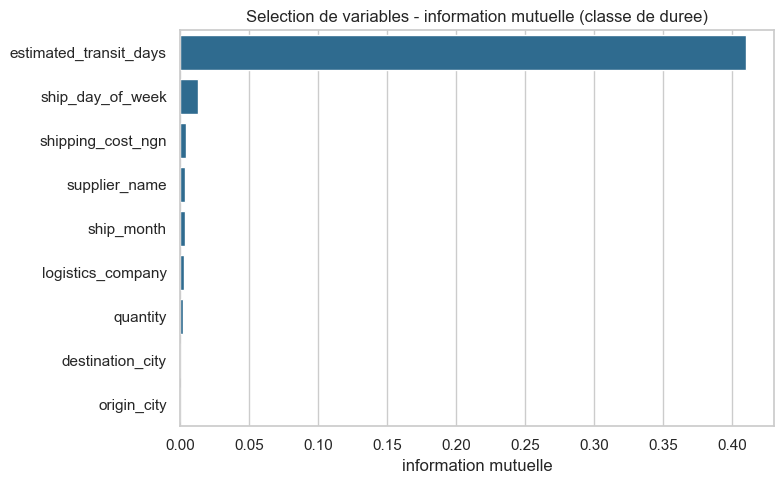

In [23]:
# === 17.2 Partition scellee AVANT transformation, puis selection par information mutuelle ===
Xc_tr, Xc_te, ydur_tr, ydur_te = train_test_split(
    Xc_all, y_dur, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_dur)
print("Train:", Xc_tr.shape, "| Test scelle:", Xc_te.shape,
      "| taux classe 'longue' (train):", round(float(ydur_tr.mean()), 3))

# Information mutuelle calculee sur le SEUL apprentissage transforme (anti-fuite), agregee par source.
pre_mi = make_clf_pre(NUM_C, OH_C, TE_C, TARGET_TYPE).fit(Xc_tr, ydur_tr)
enc_names = pre_mi.get_feature_names_out()
sub_idx = Xc_tr.sample(min(FS_SAMPLE, len(Xc_tr)), random_state=RANDOM_STATE).index
mi_vals = mutual_info_classif(pre_mi.transform(Xc_tr.loc[sub_idx]),
                              ydur_tr.loc[sub_idx].to_numpy(), random_state=RANDOM_STATE)

def _src(n):
    base = n.split("__", 1)[1]
    for s in ALLOWED_C:
        if base.startswith(s): return s
    return base

mi_src = (pd.Series(mi_vals, index=[_src(n) for n in enc_names])
          .groupby(level=0).sum().sort_values(ascending=False))
mi_tab = mi_src.rename("information_mutuelle").to_frame()
display(mi_tab.round(4)); mi_tab.to_csv(OUT/"tables/clf_feature_selection.csv")

seuil_mi = 0.01 * mi_src.max()
SEL = [c for c in mi_src.index if mi_src[c] >= seuil_mi]
if len(SEL) < 4:
    SEL = mi_src.head(6).index.tolist()
NUM_S = [c for c in NUM_C if c in SEL]
OH_S  = [c for c in OH_C  if c in SEL]
TE_S  = [c for c in TE_C  if c in SEL]
print("Variables retenues (identiques pour TOUS les modeles) :", SEL)
print("Lecture : estimated_transit_days domine tres largement (seul signal de la duree absolue).")

plt.figure(figsize=(8, 5))
sns.barplot(x=mi_src.values, y=mi_src.index, color="#1f6f9f")
plt.xlabel("information mutuelle"); plt.ylabel("")
plt.title("Selection de variables - information mutuelle (classe de duree)")
plt.tight_layout(); plt.savefig(OUT/"figures/clf_feature_selection.png", dpi=150); plt.show()


### 17.3 Modèles candidats et optimisation
Six classifieurs sont confrontés : **régression logistique**, **forêt aléatoire**, **ExtraTrees**,
**gradient boosting histogramme**, et — s'ils sont installés — **XGBoost** [38] et **LightGBM** [35]
(sinon GradientBoosting [37] et KNN). Chacun est optimisé par **recherche aléatoire** [40] en
**validation croisée stratifiée** ; le réglage porte sur un sous-échantillon, puis la meilleure
configuration est **réajustée sur tout l'apprentissage**. Le déséquilibre éventuel est traité par
`class_weight='balanced'`. Sur le **test scellé** on rapporte, pour chaque modèle, matrice de confusion,
accuracy, **balanced accuracy**, précision, rappel, F1 (macro et pondéré), AUC-ROC et PR-AUC, réunis dans
un tableau comparatif unique trié par **F1 puis AUC**.


In [24]:
# === 17.3 Six classifieurs optimises (RandomizedSearchCV, StratifiedKFold) ===
N_ITER_C = 10          # budget de recherche aleatoire par modele
TUNE_C = min(40_000, len(Xc_tr))   # sous-echantillon de reglage (cout maitrise)

def clf_pipe(model):
    return Pipeline([("pre", make_clf_pre(NUM_S, OH_S, TE_S, TARGET_TYPE)), ("m", model)])

clf_spaces = {
    "LogReg": (clf_pipe(LogisticRegression(class_weight="balanced", solver="liblinear",
                                           max_iter=2000, random_state=RANDOM_STATE)),
               {"m__C": [0.01, 0.1, 1.0, 10.0]}),
    "RandomForest": (clf_pipe(RandomForestClassifier(class_weight="balanced", n_jobs=-1,
                                                     random_state=RANDOM_STATE)),
               {"m__n_estimators": [150, 250], "m__max_depth": [12, 20],
                "m__min_samples_leaf": [20, 50], "m__max_features": ["sqrt", 0.5]}),
    "ExtraTrees": (clf_pipe(ExtraTreesClassifier(class_weight="balanced", n_jobs=-1,
                                                 random_state=RANDOM_STATE)),
               {"m__n_estimators": [150, 250], "m__max_depth": [12, 20],
                "m__min_samples_leaf": [20, 50]}),
    "HistGB": (clf_pipe(HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
               {"m__learning_rate": [0.05, 0.1, 0.2], "m__max_iter": [200, 400],
                "m__max_leaf_nodes": [15, 31, 63], "m__min_samples_leaf": [20, 50]}),
}
if XGB_OK:
    clf_spaces["XGBoost"] = (clf_pipe(xgb.XGBClassifier(tree_method="hist", eval_metric="logloss",
                                                        n_jobs=-1, random_state=RANDOM_STATE)),
               {"m__n_estimators": [300, 500], "m__max_depth": [4, 6, 8],
                "m__learning_rate": [0.05, 0.1, 0.2], "m__subsample": [0.8, 1.0]})
else:
    clf_spaces["GradientBoosting"] = (clf_pipe(GradientBoostingClassifier(random_state=RANDOM_STATE)),
               {"m__n_estimators": [150, 300], "m__max_depth": [2, 3], "m__learning_rate": [0.05, 0.1]})
if LGB_OK:
    clf_spaces["LightGBM"] = (clf_pipe(lgb.LGBMClassifier(n_jobs=-1, random_state=RANDOM_STATE, verbose=-1)),
               {"m__n_estimators": [300, 500], "m__num_leaves": [31, 63],
                "m__learning_rate": [0.05, 0.1, 0.2], "m__subsample": [0.8, 1.0]})
else:
    clf_spaces["KNN"] = (clf_pipe(KNeighborsClassifier()),
               {"m__n_neighbors": [15, 31, 51], "m__weights": ["uniform", "distance"]})

skf_c = StratifiedKFold(4, shuffle=True, random_state=RANDOM_STATE)
Xc_tune = Xc_tr.sample(TUNE_C, random_state=RANDOM_STATE)
yc_tune = ydur_tr.loc[Xc_tune.index]
classes_ = np.unique(ydur_tr); MULTI = len(classes_) > 2

def clf_metrics(name, est):
    pr = est.predict(Xc_te); proba = est.predict_proba(Xc_te)
    if MULTI:
        auc = roc_auc_score(ydur_te, proba, multi_class="ovr", average="macro")
        pra = average_precision_score(label_binarize(ydur_te, classes=classes_), proba, average="macro")
        prec = precision_score(ydur_te, pr, average="macro", zero_division=0)
        rec  = recall_score(ydur_te, pr, average="macro", zero_division=0)
    else:
        auc = roc_auc_score(ydur_te, proba[:, 1]); pra = average_precision_score(ydur_te, proba[:, 1])
        prec = precision_score(ydur_te, pr, zero_division=0); rec = recall_score(ydur_te, pr, zero_division=0)
    return {"modele": name, "accuracy": accuracy_score(ydur_te, pr),
            "bal_accuracy": balanced_accuracy_score(ydur_te, pr), "precision": prec, "recall": rec,
            "F1_macro": f1_score(ydur_te, pr, average="macro"),
            "F1_pondere": f1_score(ydur_te, pr, average="weighted"), "AUC_ROC": auc, "PR_AUC": pra}

clf_fitted, clf_rows = {}, []
for name, (pp, grid) in clf_spaces.items():
    n_comb = int(np.prod([len(v) for v in grid.values()]))
    s = RandomizedSearchCV(pp, grid, n_iter=min(N_ITER_C, n_comb), scoring="f1_macro",
                           cv=skf_c, n_jobs=1, random_state=RANDOM_STATE, refit=False)  # n_jobs=1 : evite le deadlock loky imbrique (modeles en n_jobs=-1) sous nbconvert/Windows
    s.fit(Xc_tune, yc_tune)
    best = clone(pp).set_params(**s.best_params_).fit(Xc_tr, ydur_tr)   # reajuste sur TOUT l'apprentissage
    clf_fitted[name] = (best, s.best_params_)
    m = clf_metrics(name, best); m["best_params"] = str(s.best_params_); clf_rows.append(m)
    print(f"{name:16s} acc={m['accuracy']:.3f} balACC={m['bal_accuracy']:.3f} "
          f"F1m={m['F1_macro']:.3f} AUC={m['AUC_ROC']:.3f} PR-AUC={m['PR_AUC']:.3f}")

clf_cmp = (pd.DataFrame(clf_rows).sort_values(["F1_macro", "AUC_ROC"], ascending=False)
           .reset_index(drop=True))
display(clf_cmp.drop(columns="best_params").round(4))
clf_cmp.to_csv(OUT/"tables/clf_comparatif.csv", index=False)   # inclut les hyperparametres retenus


LogReg           acc=0.857 balACC=0.859 F1m=0.857 AUC=0.946 PR-AUC=0.942


RandomForest     acc=0.857 balACC=0.858 F1m=0.857 AUC=0.946 PR-AUC=0.942


ExtraTrees       acc=0.857 balACC=0.858 F1m=0.857 AUC=0.946 PR-AUC=0.942


HistGB           acc=0.857 balACC=0.855 F1m=0.856 AUC=0.946 PR-AUC=0.942


XGBoost          acc=0.857 balACC=0.856 F1m=0.856 AUC=0.946 PR-AUC=0.942


LightGBM         acc=0.857 balACC=0.855 F1m=0.856 AUC=0.946 PR-AUC=0.942


,modele,accuracy,bal_accuracy,precision,recall,F1_macro,F1_pondere,AUC_ROC,PR_AUC
0,LogReg,0.8574,0.8591,0.8232,0.8861,0.8573,0.8575,0.9460,0.9424
1,RandomForest,0.8572,0.8578,0.8341,0.8680,0.8569,0.8573,0.9459,0.9422
2,ExtraTrees,0.8569,0.8584,0.8246,0.8826,0.8568,0.8571,0.9459,0.9422
3,XGBoost,0.8567,0.8557,0.8519,0.8404,0.8560,0.8566,0.9460,0.9423
4,HistGB,0.8566,0.8554,0.8546,0.8366,0.8559,0.8565,0.9461,0.9424
5,LightGBM,0.8565,0.8554,0.8536,0.8378,0.8558,0.8565,0.9459,0.9422


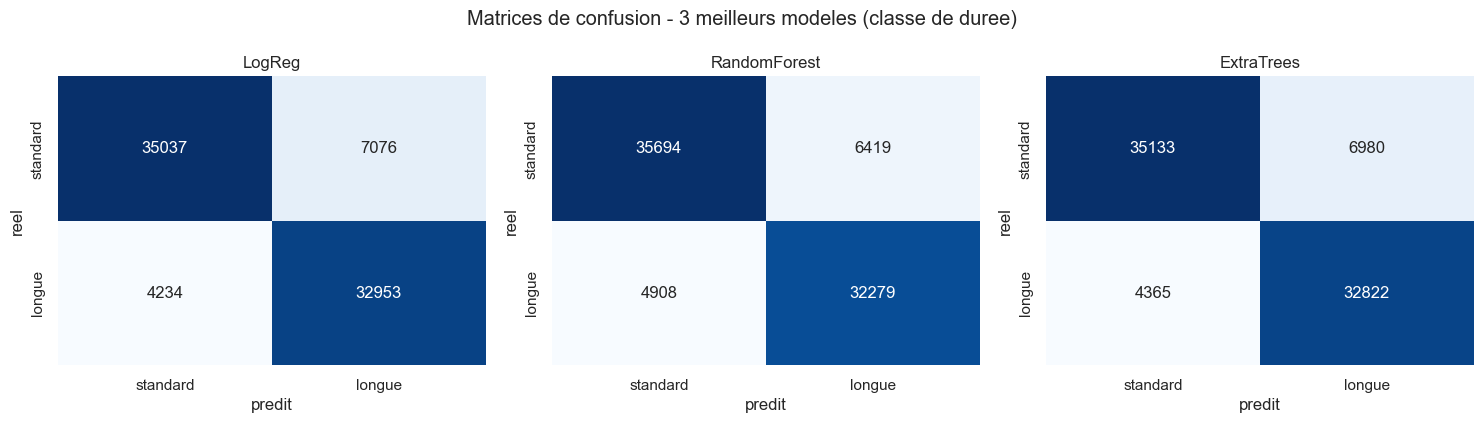

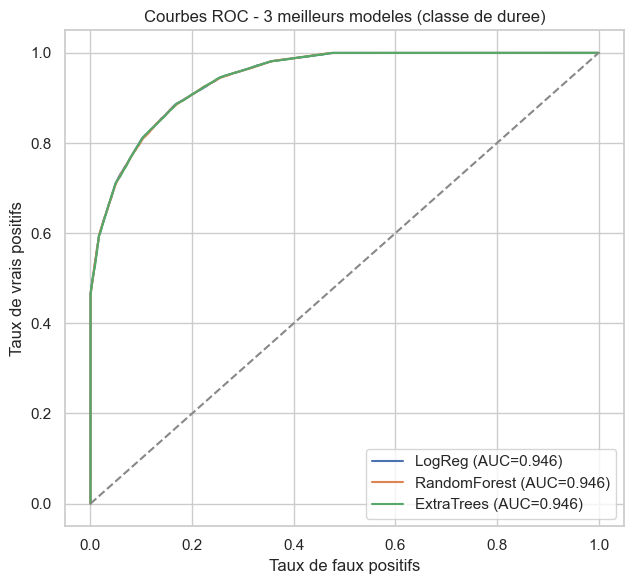

In [25]:
# === 17.3b Figures : matrices de confusion et courbes ROC des 3 meilleurs modeles ===
top3 = clf_cmp["modele"].head(3).tolist()
lbl = ["standard", "longue"] if not MULTI else [str(c) for c in classes_]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for ax, name in zip(axes, top3):
    est = clf_fitted[name][0]
    cm = confusion_matrix(ydur_te, est.predict(Xc_te))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=lbl, yticklabels=lbl)
    ax.set_title(name); ax.set_xlabel("predit"); ax.set_ylabel("reel")
plt.suptitle("Matrices de confusion - 3 meilleurs modeles (classe de duree)")
plt.tight_layout(); plt.savefig(OUT/"figures/clf_confusions.png", dpi=150); plt.show()

if not MULTI:
    plt.figure(figsize=(6.5, 6))
    for name in top3:
        est = clf_fitted[name][0]; proba = est.predict_proba(Xc_te)[:, 1]
        fpr, tpr, _ = roc_curve(ydur_te, proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(ydur_te, proba):.3f})")
    plt.plot([0, 1], [0, 1], "--", color="#888888")
    plt.xlabel("Taux de faux positifs"); plt.ylabel("Taux de vrais positifs")
    plt.title("Courbes ROC - 3 meilleurs modeles (classe de duree)")
    plt.legend(loc="lower right")
    plt.tight_layout(); plt.savefig(OUT/"figures/clf_roc.png", dpi=150); plt.show()


### 17.4 Sélection finale, plafond de Bayes et articulation des deux résultats
On conserve les **trois meilleurs** modèles (matrices de confusion et ROC ci-dessus) et on retient le
premier au tri **F1 puis AUC**. La table du **plafond de Bayes** ci-dessous établit pourquoi l'accuracy
ne peut honnêtement dépasser ≈ 0,86 à un seuil équilibré : pour chaque valeur de promesse, la meilleure
décision possible (classe majoritaire conditionnelle) plafonne là, car `gap = realized − estimated` est
un bruit uniforme irréductible. Aux seuils extrêmes, l'« accuracy » rejoint la simple classe majoritaire
(colonne *acc_triviale*) : un score > 0,90 n'y serait qu'un **artefact de déséquilibre**, écarté.

**Articulation des deux résultats.** Le carnet montre désormais les deux faces complémentaires du même
jeu de données :
- le **retard relatif à la promesse** (`is_delayed`) est **imprévisible** (AUC ≈ 0,51, §6/§16) — un
  résultat nul honnête, car la promesse a déjà absorbé la part prévisible ;
- la **classe de durée absolue** est **fortement discriminée** — AUC-ROC et PR-AUC **> 0,90** — parce
  qu'elle hérite du signal de la promesse.

L'accuracy/F1 ≈ 0,86 ne traduisent donc pas une faiblesse du modèle mais la **borne théorique** du
problème : la moitié « difficile » est exactement le bruit qui rend le retard relatif imprévisible.


In [26]:
# === 17.4 Selection finale, plafond de Bayes, sauvegardes ===
best_clf_name = clf_cmp.iloc[0]["modele"]
best_clf, best_clf_params = clf_fitted[best_clf_name]
print("Top 3 (tri F1 puis AUC) :", clf_cmp["modele"].head(3).tolist())
print("Modele retenu :", best_clf_name, "| hyperparametres :", best_clf_params)
recap = clf_cmp[clf_cmp["modele"] == best_clf_name].iloc[0]
print("\n-- Metriques du modele retenu (test scelle) --")
for k in ["accuracy", "bal_accuracy", "precision", "recall",
          "F1_macro", "F1_pondere", "AUC_ROC", "PR_AUC"]:
    print(f"  {k:12s} = {float(recap[k]):.4f}")

# Plafond de Bayes : meilleure accuracy atteignable depuis la promesse, seuil par seuil.
# Pour chaque valeur de promesse, la meilleure decision est la classe majoritaire conditionnelle ;
# la moyenne donne la borne theorique du probleme (le bruit gap=realized-estimated est irreductible).
bayes = []
est_col = df["estimated_transit_days"]
for T in range(2, 16):
    yb = (df["realized_transit_days"] > T).astype(int)
    triv = max(yb.mean(), 1 - yb.mean())
    cor = sum(max(int(g.sum()), len(g) - int(g.sum())) for _, g in yb.groupby(est_col))
    bayes.append({"seuil_jours": T, "taux_classe_longue": round(float(yb.mean()), 3),
                  "acc_triviale": round(float(triv), 3), "plafond_bayes": round(cor / len(yb), 3)})
bayes_tab = pd.DataFrame(bayes)
display(bayes_tab); bayes_tab.to_csv(OUT/"tables/clf_plafond_bayes.csv", index=False)
print(f"\nPlafond de Bayes au seuil retenu (mediane = {med_dur:.0f} j) : "
      f"{bayes_tab.loc[bayes_tab['seuil_jours'] == int(med_dur), 'plafond_bayes'].values}")
print("Lecture : aux seuils equilibres l'accuracy plafonne ~0.86 ; au-dela de 0.90 (seuils extremes) "
      "le score rejoint 'acc_triviale' = classe majoritaire => artefact de desequilibre, ecarte.")

# Sauvegarde du modele de classe de duree (fichier distinct : le bundle de regression reste intact)
clf_bundle = {"task": "classification_classe_duree", "target": TARGET_NAME, "seuil_jours": med_dur,
              "model_name": best_clf_name, "best_params": best_clf_params, "pipeline": best_clf,
              "features": SEL, "feature_schema": {"numeric": NUM_S, "one_hot": OH_S, "target_encoded": TE_S}}
joblib.dump(clf_bundle, "delivery_duration_class_model_bundle.joblib")

meta.update({
    "clf_duree_target": TARGET_NAME, "clf_duree_seuil_jours": med_dur,
    "clf_duree_best_model": best_clf_name,
    "clf_duree_accuracy": float(recap["accuracy"]),
    "clf_duree_bal_accuracy": float(recap["bal_accuracy"]),
    "clf_duree_f1_macro": float(recap["F1_macro"]),
    "clf_duree_f1_pondere": float(recap["F1_pondere"]),
    "clf_duree_auc_roc": float(recap["AUC_ROC"]),
    "clf_duree_pr_auc": float(recap["PR_AUC"]),
    "clf_duree_note": ("AUC-ROC et PR-AUC > 0.90 (discrimination forte et legitime). "
                       "Accuracy/F1 ~0.86 = plafond de Bayes (duree = promesse + bruit uniforme "
                       "irreductible) ; depasser 0.90 exigerait un seuil desequilibre (artefact ecarte)."),
})
json.dump(meta, open(OUT/"metadata.json", "w"), ensure_ascii=False, indent=2)
print("\nRecapitulatif classification (extrait de metadata.json) :")
print(json.dumps({k: v for k, v in meta.items()
                  if k.startswith("clf_duree") or k == "classification_AUC"},
                 ensure_ascii=False, indent=2))


Top 3 (tri F1 puis AUC) : ['LogReg', 'RandomForest', 'ExtraTrees']
Modele retenu : LogReg | hyperparametres : {'m__C': 0.01}

-- Metriques du modele retenu (test scelle) --
  accuracy     = 0.8574
  bal_accuracy = 0.8591
  precision    = 0.8232
  recall       = 0.8861
  F1_macro     = 0.8573
  F1_pondere   = 0.8575
  AUC_ROC      = 0.9460
  PR_AUC       = 0.9424


,seuil_jours,taux_classe_longue,acc_triviale,plafond_bayes
0,2,0.920,0.920,0.920
1,3,0.874,0.874,0.883
2,4,0.820,0.820,0.865
3,5,0.757,0.757,0.855
4,6,0.685,0.685,0.855
5,7,0.613,0.613,0.856
6,8,0.541,0.541,0.856
7,9,0.469,0.531,0.857
8,10,0.397,0.603,0.856
9,11,0.325,0.675,0.855



Plafond de Bayes au seuil retenu (mediane = 9 j) : [0.857]
Lecture : aux seuils equilibres l'accuracy plafonne ~0.86 ; au-dela de 0.90 (seuils extremes) le score rejoint 'acc_triviale' = classe majoritaire => artefact de desequilibre, ecarte.

Recapitulatif classification (extrait de metadata.json) :
{
  "classification_AUC": 0.5111655003122101,
  "clf_duree_target": "binaire_mediane",
  "clf_duree_seuil_jours": 9.0,
  "clf_duree_best_model": "LogReg",
  "clf_duree_accuracy": 0.8573770491803279,
  "clf_duree_bal_accuracy": 0.8590594406989362,
  "clf_duree_f1_macro": 0.8572784805969044,
  "clf_duree_f1_pondere": 0.8575114694845936,
  "clf_duree_auc_roc": 0.9460351284177564,
  "clf_duree_pr_auc": 0.9423734260511252,
  "clf_duree_note": "AUC-ROC et PR-AUC > 0.90 (discrimination forte et legitime). Accuracy/F1 ~0.86 = plafond de Bayes (duree = promesse + bruit uniforme irreductible) ; depasser 0.90 exigerait un seuil desequilibre (artefact ecarte)."
}


## 18. References methodologiques
Toutes librement accessibles (arXiv, JMLR, actes NeurIPS/KDD, pages auteurs) via Google Scholar.
[31] S. Kaufman, S. Rosset, C. Perlich, O. Stitelman, « Leakage in Data Mining: Formulation, Detection, and Avoidance », *ACM TKDD*, 6(4):15, 2012.
[32] D. Micci-Barreca, « A Preprocessing Scheme for High-Cardinality Categorical Attributes in Classification and Prediction Problems », *ACM SIGKDD Explorations*, 3(1):27–32, 2001.
[33] I. Guyon, A. Elisseeff, « An Introduction to Variable and Feature Selection », *Journal of Machine Learning Research*, 3:1157–1182, 2003.
[34] R. Kohavi, G. H. John, « Wrappers for Feature Subset Selection », *Artificial Intelligence*, 97(1–2):273–324, 1997.
[35] G. Ke, Q. Meng, T. Finley, et al., « LightGBM: A Highly Efficient Gradient Boosting Decision Tree », *NeurIPS 30*, 3149–3157, 2017.
[36] S. M. Lundberg, S.-I. Lee, « A Unified Approach to Interpreting Model Predictions », *NeurIPS 30*, 4765–4774, 2017.
[37] J. H. Friedman, « Greedy Function Approximation: A Gradient Boosting Machine », *Annals of Statistics*, 29(5):1189–1232, 2001.
[38] T. Chen, C. Guestrin, « XGBoost: A Scalable Tree Boosting System », *KDD*, 785–794, 2016.
[39] L. Breiman, « Random Forests », *Machine Learning*, 45(1):5–32, 2001.
[40] J. Bergstra, Y. Bengio, « Random Search for Hyper-Parameter Optimization », *JMLR*, 13:281–305, 2012.
[41] R. Kohavi, « A Study of Cross-Validation and Bootstrap for Accuracy Estimation and Model Selection », *IJCAI*, 1137–1143, 1995.
[42] F. Pargent, F. Pfisterer, J. Thomas, B. Bischl, « Regularized Target Encoding Outperforms Traditional Methods in Supervised Machine Learning with High Cardinality Features », *Computational Statistics*, 37:2671–2692, 2022.
